In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class VQADataset(Dataset):
    def __init__(self, num_samples=500, max_len=16):
        self.num_samples = num_samples
        self.max_len = max_len
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        question = "What is in the image?"
        encoding = self.tokenizer(question, return_tensors="pt", padding="max_length", truncation=True, max_length=self.max_len)
        text_inputs = {k: v.squeeze(0) for k, v in encoding.items()}
        image_feature = torch.randn(2048)
        label = torch.tensor(np.random.randint(0, 10))
        return text_inputs, image_feature, label

In [3]:
class VisualBERT(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.text_encoder = BertModel.from_pretrained("bert-base-uncased")
        self.img_fc = nn.Linear(2048, 768)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, text_inputs, img_feats):
        text_outputs = self.text_encoder(**text_inputs)
        text_cls = text_outputs.last_hidden_state[:, 0, :]
        img_emb = self.img_fc(img_feats)
        fused = text_cls + img_emb
        return self.classifier(fused)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(VQADataset(300), batch_size=16, shuffle=True)
val_loader = DataLoader(VQADataset(50), batch_size=16)

model = VisualBERT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 200

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [5]:
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for text_inputs, img_feats, labels in train_loader:
        text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
        img_feats, labels = img_feats.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(text_inputs, img_feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for text_inputs, img_feats, labels in val_loader:
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
            img_feats, labels = img_feats.to(device), labels.to(device)
            outputs = model(text_inputs, img_feats)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / val_total)
    print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Acc {train_accs[-1]:.2f}, Val {val_losses[-1]:.4f}, Acc {val_accs[-1]:.2f}")

Epoch 1: Train 2.3820, Acc 0.12, Val 2.3759, Acc 0.10
Epoch 2: Train 2.4113, Acc 0.11, Val 2.2806, Acc 0.14
Epoch 3: Train 2.4198, Acc 0.08, Val 2.3512, Acc 0.10
Epoch 4: Train 2.3648, Acc 0.10, Val 2.3755, Acc 0.12
Epoch 5: Train 2.3869, Acc 0.09, Val 2.3546, Acc 0.10
Epoch 6: Train 2.3482, Acc 0.10, Val 2.3603, Acc 0.08
Epoch 7: Train 2.3956, Acc 0.09, Val 2.3261, Acc 0.06
Epoch 8: Train 2.3736, Acc 0.08, Val 2.2980, Acc 0.10
Epoch 9: Train 2.4210, Acc 0.08, Val 2.4241, Acc 0.12
Epoch 10: Train 2.3712, Acc 0.12, Val 2.5348, Acc 0.08
Epoch 11: Train 2.3350, Acc 0.11, Val 2.6073, Acc 0.12
Epoch 12: Train 2.4418, Acc 0.08, Val 2.3487, Acc 0.16
Epoch 13: Train 2.4364, Acc 0.10, Val 2.2801, Acc 0.10
Epoch 14: Train 2.3879, Acc 0.11, Val 2.3683, Acc 0.04
Epoch 15: Train 2.4145, Acc 0.11, Val 2.4269, Acc 0.12
Epoch 16: Train 2.3930, Acc 0.12, Val 2.4726, Acc 0.04
Epoch 17: Train 2.4307, Acc 0.11, Val 2.3758, Acc 0.12
Epoch 18: Train 2.4090, Acc 0.09, Val 2.3305, Acc 0.06
Epoch 19: Train 2.4

In [6]:
sample_text, sample_img, _ = VQADataset()[0]
sample_text = {k: v.unsqueeze(0).to(device) for k, v in sample_text.items()}
sample_img = sample_img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred = model(sample_text, sample_img)
    pred_class = torch.argmax(pred, dim=1).item()

print("Predicted class:", pred_class)

Predicted class: 2


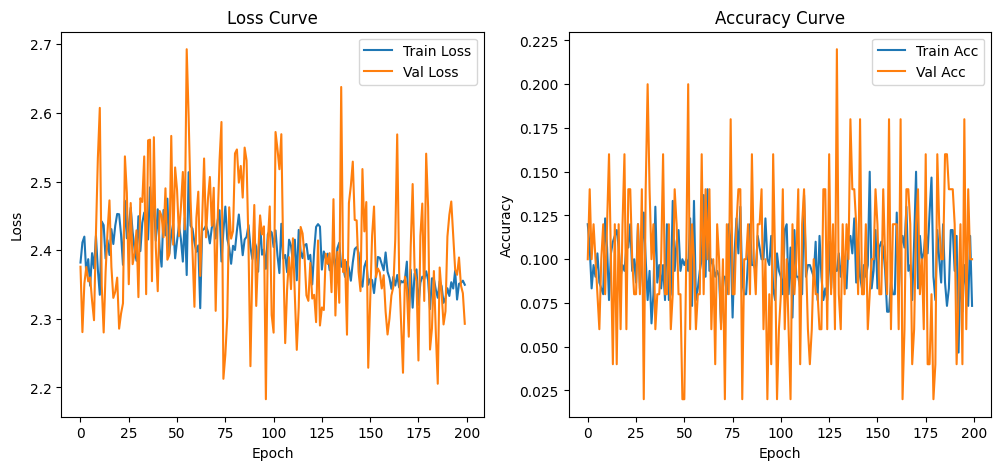

In [7]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()